# 2. Model: MDP, politika i učenje

Šta se ovde pokazuje: kako se projektovanje mreže pretvara u niz odluka, kako
izgleda mreža koja te odluke donosi, i zašto se uči REINFORCE-om a ne
klasičnim supervizovanim učenjem.

Ovo je deo koji se ne vidi iz tabela.

In [1]:
import sys
from pathlib import Path

KOREN = Path.cwd().parent
sys.path.insert(0, str(KOREN))

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## 2.1 MDP

Epizoda gradi svih R linija redom. Za svaku liniju prvo se bira početni čvor,
pa se naizmenično bira proširenje ili kraj. Akcija je par (kraj, čvor).

Zato što linija raste na oba kraja. Da je akcija samo čvor, za čvor koji je susedan
i početku i repu bila bi dostižna samo jedna od dve linije koje iz njega nastaju.

Nije rubni slučaj: na Delaunay grafovima 40% poteza nudi bar jedan takav čvor
(`python -m tndp.experiments.checks`, provera 8).

In [2]:
from tndp.rl.env import TndpEnv, EXTEND, HALT, HEAD, TAIL
from tndp.core.synth import generate_city

grad = generate_city(seed=0, n_range=(12, 16))
env = TndpEnv(grad, num_routes=3, min_len=2, max_len=8, alpha=0.5)

odluka, maska = env.decision()
print("tip odluke:", "EXTEND" if odluka == EXTEND else "HALT")
print("oblik maske:", maska.shape, "  dozvoljenih poteza:", maska.sum())
print("dozvoljeni pocetni cvorovi:", np.flatnonzero(maska[HEAD]))

tip odluke: EXTEND
oblik maske: (2, 16)   dozvoljenih poteza: 16
dozvoljeni pocetni cvorovi: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


## 2.2 Jedna epizoda, potez po potez

Vidi se da pravila drži maska, ne nagrada. Na startu linije dozvoljeni su samo
terminali. Kod linije od jednog čvora dozvoljen je samo `TAIL`, jer bi `HEAD` dao
istu liniju obrnutim redosledom. `halt` se pojavljuje tek kad je dužina u
dozvoljenom opsegu, oba kraja su dozvoljeni terminali i linija nije duplikat već
sagrađene.

Pošto nedozvoljen potez nikad nema verovatnoću, trening ne troši nijedan uzorak na
učenje pravila koja su ionako poznata.

In [3]:
import torch
from tndp.rl.model import TndpPolicy
from tndp.rl.features import node_features, edge_tensors

torch.manual_seed(0)
policy = TndpPolicy()
ei, ea = edge_tensors(grad)
env.reset()

korak = 0
while not env.done and korak < 25:
    odluka, maska = env.decision()
    h = policy.encode(node_features(env, policy.features), ei, ea)
    logiti = policy.action_logits(h, odluka, maska, env.ends)
    p = torch.distributions.Categorical(logits=logiti)
    a = int(torch.multinomial(p.probs, 1))
    kraj = (odluka == HALT and a == len(logiti) - 1)
    print(f"{korak:2d}  linija {len(env.routes)}  tekuca {env.current}  "
          f"{'KRAJ LINIJE' if kraj else f'dodaj cvor {a % grad.n}'}")
    env.step(-1 if kraj else a)
    korak += 1

print("\nmreza:", env.routes)

 0  linija 0  tekuca []  dodaj cvor 3
 1  linija 0  tekuca [3]  dodaj cvor 14
 2  linija 0  tekuca [3, 14]  KRAJ LINIJE
 3  linija 1  tekuca []  dodaj cvor 12
 4  linija 1  tekuca [12]  dodaj cvor 5
 5  linija 1  tekuca [12, 5]  KRAJ LINIJE
 6  linija 2  tekuca []  dodaj cvor 2
 7  linija 2  tekuca [2]  dodaj cvor 13
 8  linija 2  tekuca [2, 13]  dodaj cvor 8
 9  linija 2  tekuca [8, 2, 13]  dodaj cvor 9
10  linija 2  tekuca [9, 8, 2, 13]  KRAJ LINIJE

mreza: [[3, 14], [12, 5], [9, 8, 2, 13]]


## 2.3 Arhitektura

GATv2 enkoder, pa tri glave: pointer za izbor čvora, halt, i value kao baseline.

MLP bi tražio ulaz fiksne dužine, dakle fiksan broj čvorova i fiksan redosled. Grad
je graf i nema prirodan redosled čvorova; permutacija oznaka daje isti problem, a
MLP bi je video kao drugi problem.

GATv2 deli iste težine preko svih čvorova i agregira po susedima, pa broj parametara
zavisi od širine sloja a ne od `n`. To nije estetika nego uslov da transfer uopšte
ima smisla: isti model se bez ijedne izmene pušta na 15 i na 127 čvorova.

In [4]:
print(policy)
print("\nparametara:", sum(p.numel() for p in policy.parameters()))
x = node_features(env, policy.features)
print("node featura:", x.shape, " edge featura:", ea.shape)

TndpPolicy(
  (embed): Linear(in_features=13, out_features=64, bias=True)
  (convs): ModuleList(
    (0-2): 3 x GATv2Conv(64, 16, heads=4)
  )
  (node_score): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (halt_score): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (value): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

parametara: 47491
node featura: torch.Size([16, 13])  edge featura: torch.Size([42, 2])


## 2.4 Nagrada

Nagrada postoji tek kad je cela mreža gotova. Oba člana su odnos prema svojoj
donjoj granici, pa `alpha` stvarno balansira.

Zasebna kazna bi bila treća konstanta koju treba podesiti, i morala bi da uđe i u
cilj klasičnih metoda, inače poređenje ne bi merilo metode nego razliku u zadatku.
Naplata kroz `C_p_all` drži jednu skalu: nepokriven par plaća `UNSERVED_FACTOR`
puta ulično najkraće vreme, dakle isti tip broja kao i opslužen par.

Ograničenje te odluke je poznato i izmereno: faktor 8 nije iznad najgoreg
opsluženog para, nego iznad 98% opslužene tražnje (`checks.py`, provera 2).

In [5]:
from tndp.core.assignment import cost_scales, objective, UNSERVED_FACTOR

nagrada, res = env.reward()
cp_scale, co_scale = cost_scales(grad)
print(f"C_p_all {res.C_p_all:.2f} / {cp_scale:.2f} = {res.C_p_all/cp_scale:.3f}   putnicki clan")
print(f"C_o     {res.C_o:.2f} / {co_scale:.2f} = {res.C_o/co_scale:.3f}   operaterski clan")
print(f"cilj {objective(res, (cp_scale, co_scale), 0.5):.3f}   nagrada {nagrada:.3f}")
print(f"d_un {res.d['d_un']:.3f}   UNSERVED_FACTOR {UNSERVED_FACTOR}")

C_p_all 32.97 / 4.39 = 7.517   putnicki clan
C_o     20.92 / 49.12 = 0.426   operaterski clan
cilj 3.971   nagrada -3.971
d_un 0.869   UNSERVED_FACTOR 8.0


## 2.5 Zašto REINFORCE

Nema tačnog odgovora sa kojim bi se izlaz poredio. Umesto toga se uzorkuje
epizoda, dobija skalar na kraju, i pojačavaju potezi koji su ispali bolji od
proseka.

Nema ciljne mreže sa kojom bi se izlaz poredio: optimalno rešenje TNDP-a nije
poznato ni za instance iz literature, pa nema oznaka za supervizovano učenje.

Umesto gradijenta greške prema poznatom izlazu, REINFORCE koristi gradijent
log-verovatnoće odigranog puta pomnožen skalarom koji stiže tek na kraju epizode.
Cena je šum: nagrada dolazi posle svih odluka, pa se ne zna koji potez je zaslužan.
Zato ide baseline (value glava) i standardizacija advantage-a unutar batch-a.

In [6]:
from tndp.rl.evaluate import rollout

env.reset()
_, nagrada, res, logp, ent = rollout(policy, env, sample=True,
                                     gen=torch.Generator().manual_seed(0))
baseline = policy.state_value(policy.encode(node_features(env.reset(), policy.features), ei, ea))
adv = nagrada - baseline.item()
loss = -(adv * logp) - 0.01 * ent
print(f"nagrada {nagrada:.3f}   baseline {baseline.item():.3f}   advantage {adv:+.3f}")
print(f"suma log verovatnoca {logp.item():.2f}   entropija {ent.item():.2f}")
print(f"loss {loss.item():.3f}")
loss.backward()
print("gradijenti konacni:", all(torch.isfinite(p.grad).all() for p in policy.parameters() if p.grad is not None))

nagrada -3.582   baseline -0.102   advantage -3.480
suma log verovatnoca -21.94   entropija 1.88
loss -76.392
gradijenti konacni: True


## 2.6 Kratak trening

Pravi modeli su u `runs/`; ovde se pušta kratak run samo da se vidi da kriva raste.

`gravity-v1` je trenirao 3000 iteracija. U `runs/gravity-v1/log.csv` je validaciona
nagrada na 3000 još rasla monotono (poslednje četvrtine -1.724, -1.709, -1.697,
-1.678) a entropija još padala (1.79 → 0.94). Dakle 3000 nije bilo odabrano po
krivi nego po raspoloživom vremenu, i model je bio nedotreniran; visoka entropija
je i razlog zašto greedy dekodiranje toliko zaostaje za samplingom.

`gravity-v2` je isti config pušten do 12000 iteracija. Stvarno utrošeno vreme svakog
runa stoji u checkpointu pod ključem `sec` i u poslednjoj koloni `log.csv`.

In [7]:
# pravi trening ide iz komandne linije, ne odavde:
#   python -m tndp.rl.train --config configs/gravity-v2.yaml
import sys, subprocess
subprocess.run([sys.executable, "-m", "tndp.rl.train",
                "--config", "configs/smoke.yaml"], cwd=KOREN, check=True)


CompletedProcess(args=['C:\\Users\\Nidza\\AppData\\Local\\Programs\\Python\\Python311\\python.exe', '-m', 'tndp.rl.train', '--config', 'configs/smoke.yaml'], returncode=0)

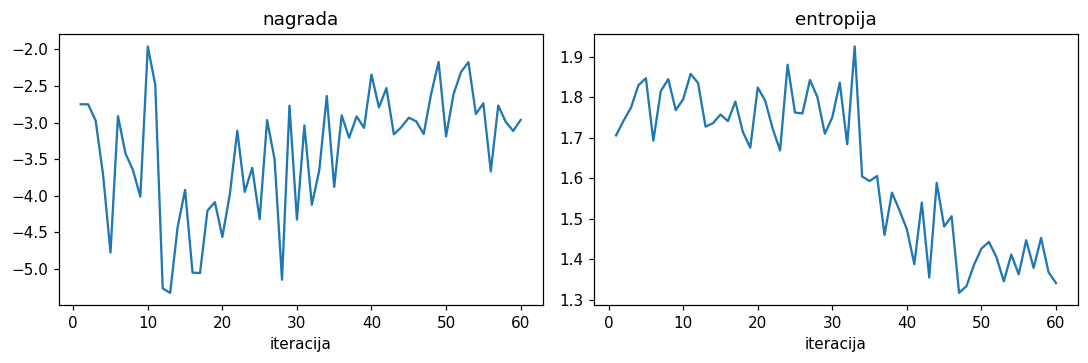

In [8]:
import csv
red = list(csv.DictReader(open(KOREN / "runs" / "smoke" / "log.csv")))
it = [int(r["iter"]) for r in red]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(it, [float(r["reward"]) for r in red]); ax[0].set_title("nagrada")
ax[1].plot(it, [float(r["entropy"]) for r in red]); ax[1].set_title("entropija")
for a in ax: a.set_xlabel("iteracija")
plt.tight_layout()
fig

## Zaključci

Pokazano je da se projektovanje mreže zapisuje kao MDP u kom je akcija par
(kraj linije, čvor), a politika je GATv2 sa maskom nedozvoljenih poteza, pa svaka
epizoda po konstrukciji daje validnu mrežu. Uči se REINFORCE-om jer ciljne mreže
za supervizovano učenje nema: postoji samo skalar na kraju epizode.
Pretpostavka je ostalo to da taj skalar nosi dovoljno signala.

Najjači nalaz je da `value(s0)` po konstrukciji vidi samo 8% varijanse nagrade,
jer 92% leži unutar istog grada, a ipak self-critical baseline, koji tu varijansu
hvata, ne popravlja rezultat: 1.519 naspram 1.534 ± 0.040 osnovne. Nije artefakt
jer je dekompozicija merena na osam gradova sa po 120 nasumičnih mreža
(`tndp.experiments.checks`, provera 7), a ablacija na dva semena i istim gradovima
kao sve ostalo. Dekompozicija dakle ne predviđa ishod.

Sledeći korak je entropija. Kod modela treniranog do konvergencije padne na 0.13,
pa 32 uzorka daju varijacije jedne ideje, što se vidi kao zaostatak na prenosu.
Entropijski bonus podignut na 0.03 i 0.1 to ne popravlja (1.523 i 1.490, unutar
rasipanja po semenu), pa bi trebalo probati kaznu koja entropiju drži iznad praga
umesto fiksnog bonusa u funkciji gubitka.